In [44]:
import numpy as np
import matplotlib.pyplot as plt

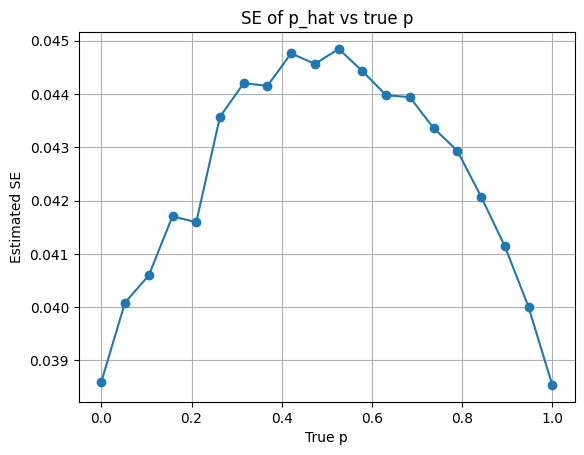

In [45]:
n = 500
num_sim = 10000

p_values = np.linspace(0, 1, 20)

se_estimates = []

for p in p_values:
    q = 1/4 + p/2
    
    p_hats = []
    
    for _ in range(num_sim):
        X = np.random.binomial(n, q)
        p_hat = 2*(X/n) - 1/2
        p_hats.append(p_hat)
    
    se = np.std(p_hats)
    se_estimates.append(se)

plt.plot(p_values, se_estimates, marker='o')
plt.xlabel("True p")
plt.ylabel("Estimated SE")
plt.title("SE of p_hat vs true p")
plt.grid()
plt.show()

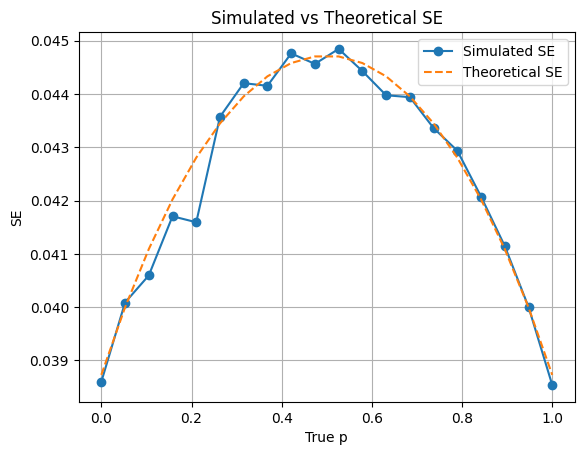

In [46]:
se_theory = []

for p in p_values:
    q = 1/4 + p/2
    se = np.sqrt(4*q*(1-q)/n)
    se_theory.append(se)

plt.plot(p_values, se_estimates, label="Simulated SE", marker='o')
plt.plot(p_values, se_theory, label="Theoretical SE", linestyle='--')
plt.legend()
plt.xlabel("True p")
plt.ylabel("SE")
plt.title("Simulated vs Theoretical SE")
plt.grid()
plt.show()

Simulation graph show that the SE is maximized around p = 0.5

In [ ]:
def estimate_max_se(n, num_sim=5000):
    p_values = np.linspace(0, 1, 10)
    max_se = 0
    
    for p in p_values:
        q = 1/4 + p/2
        p_hats = []
        
        for _ in range(num_sim):
            X = np.random.binomial(n, q)
            p_hat = 2*(X/n) - 1/2
            p_hats.append(p_hat)
        
        se = np.std(p_hats)
        max_se = max(max_se, se)
    
    return max_se


n = 1000

while True:
    max_se = estimate_max_se(n)
    
    if max_se < 0.01:
        print("Minimum n found:", n)
        break
    
    n += 100 # use 1 would be more precise but too slow, so I increase in steps of 100

Minimum n found: 10100


The minimum number is found approximatly 10000

In [49]:
n_min = int((1/0.01)**2) + 1
print("Theoretical minimum n:", n_min)

Theoretical minimum n: 10001
